## Our Findings
To find the best neighborhood in Pittsburgh we decided to take a look at these three datasets:

### Data Set 1 - Crime 
- Focused on neighborhood safety by measuring the Total reported crime incidents that occurred in 2024.
### Data Set 2 - Employment 
- Assessed employment opportunities by calculating the Percentage of the population (over age 16) that is working in the labor force.
### Data Set 3 - Traffic Safety
- evaluated traffic consistency by calculating the Average Speed Spread Score, which is based on the difference between the fast drivers (85th percentile speed) and the average drivers (50th percentile speed).

## Analysis


TOP 10 BEST NEIGHBORHOODS IN PITTSBURGH
--------------------------------------------------
 1. Friendship                     Score: 0.9261
 2. South Shore                    Score: 0.7867
 3. Polish Hill                    Score: 0.7749
 4. Allegheny West                 Score: 0.7644
 5. Fairywood                      Score: 0.7635
 6. East Carnegie                  Score: 0.7554
 7. Upper Hill                     Score: 0.7475
 8. Morningside                    Score: 0.7410
 9. Chartiers City                 Score: 0.7342
10. Summer Hill                    Score: 0.7335

BOTTOM 10 NEIGHBORHOODS
--------------------------------------------------
97. Central Business District      Score: 0.2432
96. South Side Flats               Score: 0.4438
95. Bluff                          Score: 0.5232
94. Marshall-Shadeland             Score: 0.5347
93. Glen Hazel                     Score: 0.5624
92. Homewood South                 Score: 0.5651
91. Carrick                        Score: 0.5661

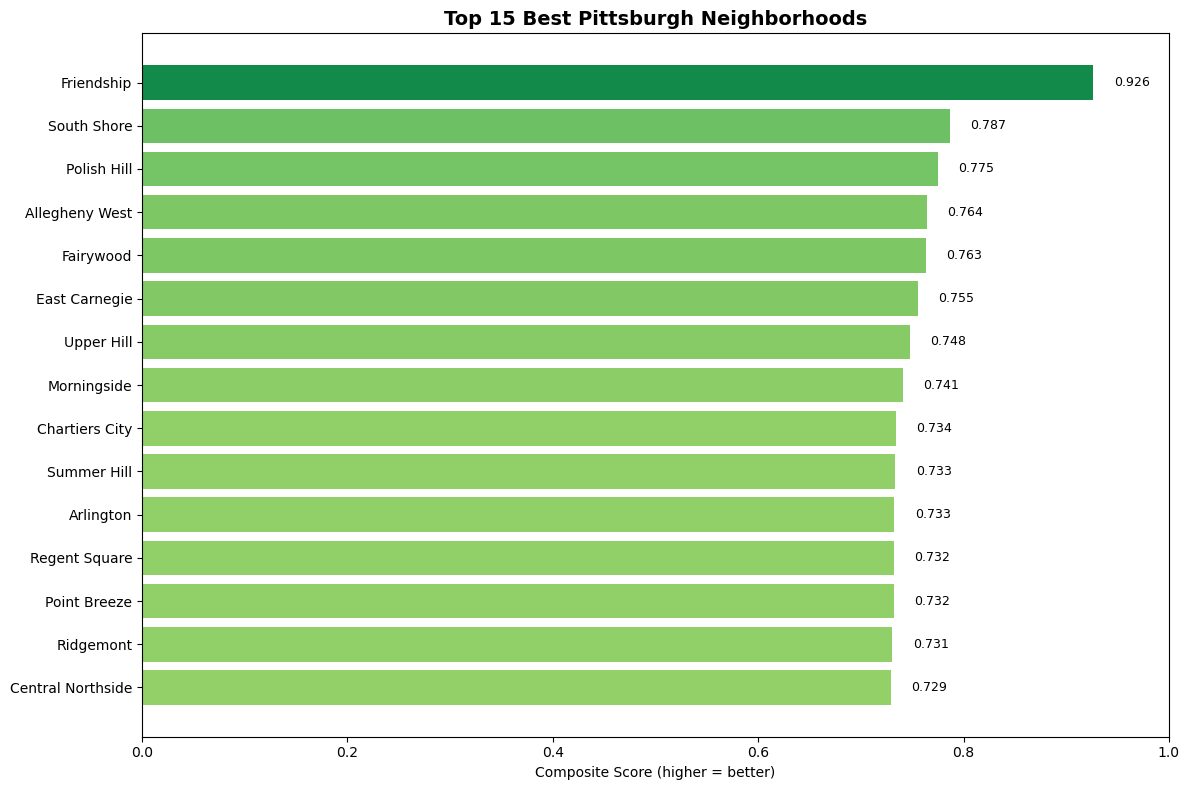

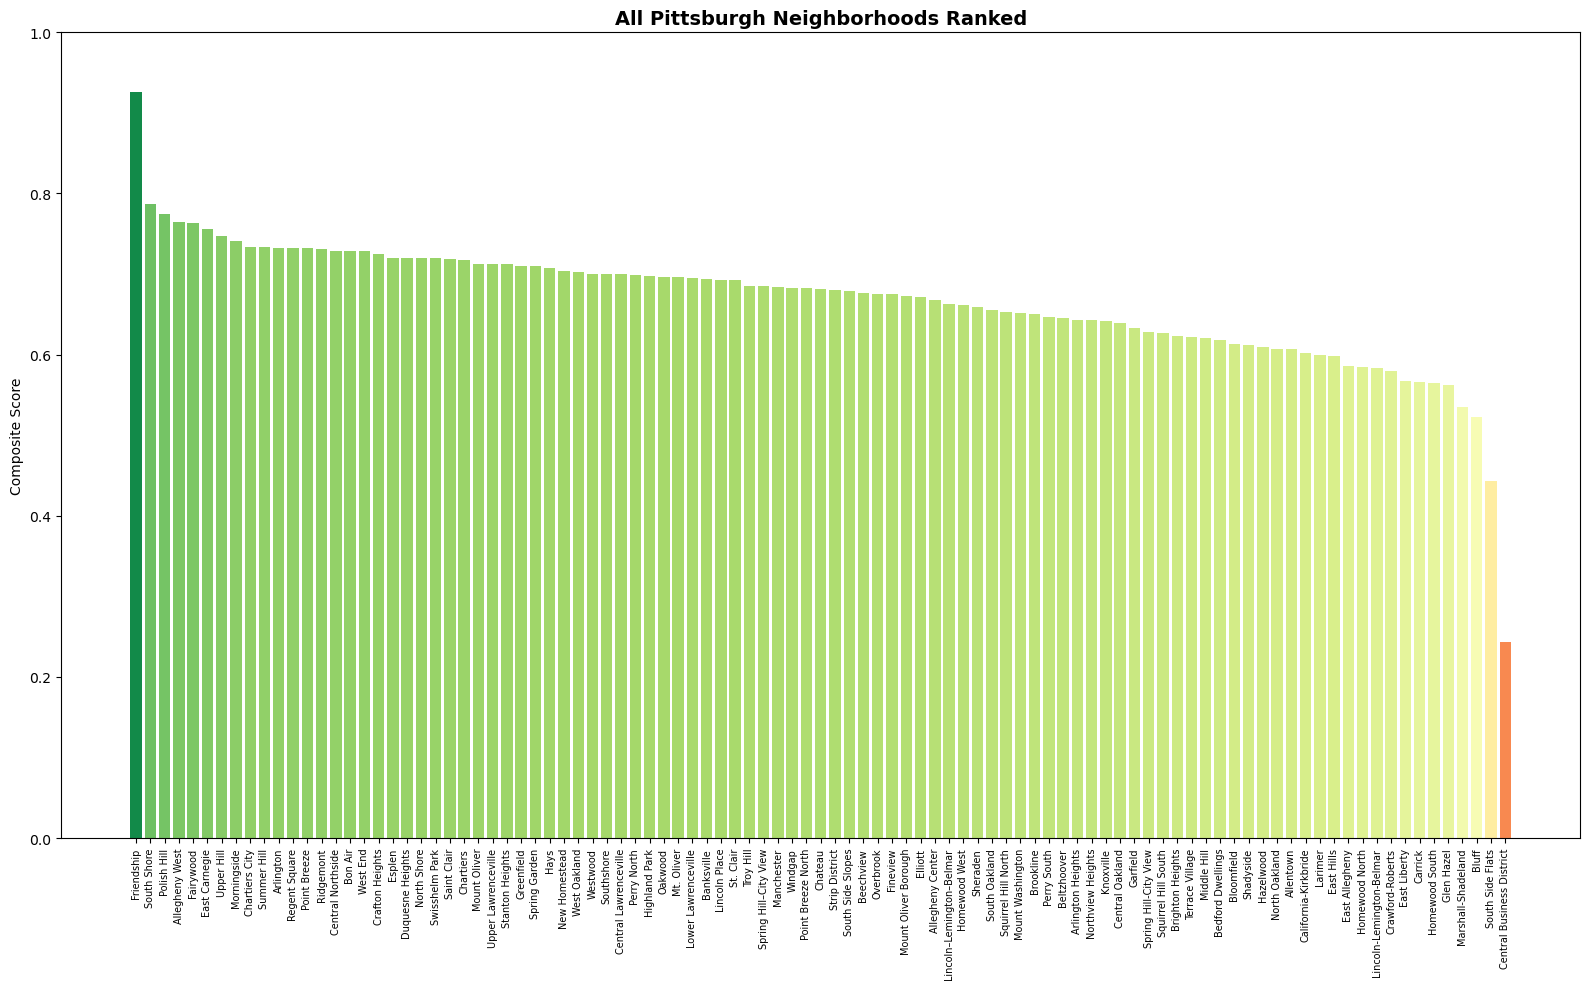


THE BEST NEIGHBORHOOD IS: FRIENDSHIP
Composite Score: 0.9261


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

TRAFFIC_FILE = "traffic.csv"
CRIME_FILE = "crime data.csv"
EMPLOYMENT_FILE = "d53bfc16-9518-4c5b-b102-847654dabe21.csv"
TARGET_YEAR = 2024
WEIGHT_TRAFFIC = 0.25
WEIGHT_CRIME = 0.50
WEIGHT_EMPLOYMENT = 0.25
OUTPUT_DIR = Path("results")

def normalize_neighborhood_name(name):
    if pd.isna(name):
        return None
    return str(name).strip().title()

def minmax_normalize(series, invert=False):
    if series.max() == series.min():
        return pd.Series(0.5, index=series.index)
    normalized = (series - series.min()) / (series.max() - series.min())
    if invert:
        return 1 - normalized
    return normalized

def process_traffic_data(filepath):
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        return None
    
    if 'speed85_percent' in df.columns and 'median_speed' in df.columns:
        df['top_50_spread'] = df['speed85_percent'] - df['median_speed']
    else:
        return None
    
    neigh_col = None
    for col in ['neighborhood', 'Neighborhood', 'NEIGHBORHOOD']:
        if col in df.columns:
            neigh_col = col
            break
    
    if neigh_col is None:
        return None
    
    traffic_metrics = df.groupby(neigh_col).agg({
        'top_50_spread': 'mean'
    }).rename(columns={'top_50_spread': 'avg_speed_spread'})
    
    traffic_metrics = traffic_metrics.dropna()
    traffic_metrics.index = traffic_metrics.index.map(normalize_neighborhood_name)
    traffic_metrics = traffic_metrics.reset_index()
    traffic_metrics.columns = ['neighborhood', 'avg_speed_spread']
    traffic_metrics['traffic_score'] = minmax_normalize(traffic_metrics['avg_speed_spread'], invert=True)
    
    return traffic_metrics[['neighborhood', 'traffic_score', 'avg_speed_spread']]

def process_crime_data(filepath, target_year=2024):
    try:
        df = pd.read_csv(filepath, low_memory=False)
    except FileNotFoundError:
        return None
    
    neigh_col = None
    for col in ['Neighborhood', 'neighborhood', 'NEIGHBORHOOD']:
        if col in df.columns:
            neigh_col = col
            break
    
    if neigh_col is None:
        return None
    
    df = df.dropna(subset=[neigh_col]).copy()
    df[neigh_col] = df[neigh_col].apply(normalize_neighborhood_name)
    
    if "ReportedDate" in df.columns:
        df["ReportedDate"] = pd.to_datetime(df["ReportedDate"], errors="coerce")
        df["year"] = df["ReportedDate"].dt.year
    elif "ReportedMonth" in df.columns:
        df["ReportedMonth"] = pd.to_datetime(df["ReportedMonth"], errors="coerce")
        df["year"] = df["ReportedMonth"].dt.year
    else:
        df["year"] = target_year
    
    df = df[df["year"] == target_year].copy()
    
    if len(df) == 0:
        df = pd.read_csv(filepath, low_memory=False)
        df = df.dropna(subset=[neigh_col]).copy()
        df[neigh_col] = df[neigh_col].apply(normalize_neighborhood_name)
    
    crime_counts = df.groupby(neigh_col).size().reset_index(name='crime_count')
    crime_counts.columns = ['neighborhood', 'crime_count']
    crime_counts['safety_score'] = minmax_normalize(crime_counts['crime_count'], invert=True)
    
    return crime_counts[['neighborhood', 'safety_score', 'crime_count']]

def process_employment_data(filepath):
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        return None
    
    df = df.rename(columns={
        "Estimate; Total:": "total_population",
        "Estimate; Not in labor force": "not_in_labor_force"
    })
    
    if 'total_population' not in df.columns or 'not_in_labor_force' not in df.columns:
        for col in df.columns:
            if 'total' in col.lower() and 'estimate' in col.lower():
                df['total_population'] = df[col]
            if 'not in labor' in col.lower():
                df['not_in_labor_force'] = df[col]
    
    if 'total_population' not in df.columns:
        return None
    
    neigh_col = None
    for col in ['Neighborhood', 'neighborhood', 'NEIGHBORHOOD']:
        if col in df.columns:
            neigh_col = col
            break
    
    if neigh_col is None:
        return None
    
    df['percent_working'] = 100 - (df['not_in_labor_force'] / df['total_population'] * 100)
    employment_metrics = df[[neigh_col, 'percent_working', 'total_population']].copy()
    employment_metrics.columns = ['neighborhood', 'percent_working', 'total_population']
    employment_metrics['neighborhood'] = employment_metrics['neighborhood'].apply(normalize_neighborhood_name)
    employment_metrics = employment_metrics.dropna()
    employment_metrics['employment_score'] = minmax_normalize(employment_metrics['percent_working'], invert=False)
    
    return employment_metrics[['neighborhood', 'employment_score', 'percent_working']]

def combine_metrics(traffic_df, crime_df, employment_df, w_traffic=WEIGHT_TRAFFIC, w_crime=WEIGHT_CRIME, w_employment=WEIGHT_EMPLOYMENT):
    dfs_to_merge = []
    available_metrics = []
    
    if traffic_df is not None:
        dfs_to_merge.append(traffic_df)
        available_metrics.append(('traffic_score', w_traffic))
    
    if crime_df is not None:
        dfs_to_merge.append(crime_df)
        available_metrics.append(('safety_score', w_crime))
    
    if employment_df is not None:
        dfs_to_merge.append(employment_df)
        available_metrics.append(('employment_score', w_employment))
    
    if len(dfs_to_merge) == 0:
        return None
    
    combined = dfs_to_merge[0]
    for df in dfs_to_merge[1:]:
        combined = pd.merge(combined, df, on='neighborhood', how='outer')
    
    total_weight = sum(w for _, w in available_metrics)
    
    combined['composite_score'] = 0
    for score_col, weight in available_metrics:
        if score_col in combined.columns:
            combined[score_col] = combined[score_col].fillna(combined[score_col].median())
            normalized_weight = weight / total_weight
            combined['composite_score'] += combined[score_col] * normalized_weight
    
    combined = combined.sort_values('composite_score', ascending=False).reset_index(drop=True)
    combined['rank'] = range(1, len(combined) + 1)
    
    return combined

def create_visualizations(combined_df, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    top15 = combined_df.head(15)
    colors = plt.cm.RdYlGn(top15['composite_score'])
    ax.barh(range(len(top15)), top15['composite_score'], color=colors)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['neighborhood'])
    ax.invert_yaxis()
    ax.set_xlabel('Composite Score (higher = better)')
    ax.set_title('Top 15 Best Pittsburgh Neighborhoods', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, (score, name) in enumerate(zip(top15['composite_score'], top15['neighborhood'])):
        ax.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(output_dir / 'top15_best_neighborhoods.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig, ax = plt.subplots(figsize=(16, 10))
    colors = plt.cm.RdYlGn(combined_df['composite_score'])
    ax.bar(range(len(combined_df)), combined_df['composite_score'], color=colors, width=0.8)
    ax.set_xticks(range(len(combined_df)))
    ax.set_xticklabels(combined_df['neighborhood'], rotation=90, fontsize=7)
    ax.set_ylabel('Composite Score')
    ax.set_title('All Pittsburgh Neighborhoods Ranked', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(output_dir / 'all_neighborhoods_ranked.png', dpi=150, bbox_inches='tight')
    plt.show()

def main():
    traffic_df = process_traffic_data(TRAFFIC_FILE)
    crime_df = process_crime_data(CRIME_FILE, TARGET_YEAR)
    employment_df = process_employment_data(EMPLOYMENT_FILE)
    
    combined = combine_metrics(traffic_df, crime_df, employment_df)
    
    if combined is None:
        print("Analysis failed - data files not found")
        return
    
    print("\nTOP 10 BEST NEIGHBORHOODS IN PITTSBURGH")
    print("-" * 50)
    for i, row in combined.head(10).iterrows():
        print(f"{row['rank']:2d}. {row['neighborhood']:<30} Score: {row['composite_score']:.4f}")
    
    print("\nBOTTOM 10 NEIGHBORHOODS")
    print("-" * 50)
    for i, row in combined.tail(10).iloc[::-1].iterrows():
        print(f"{row['rank']:2d}. {row['neighborhood']:<30} Score: {row['composite_score']:.4f}")
    
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    combined.to_csv(OUTPUT_DIR / 'neighborhood_rankings.csv', index=False)
    create_visualizations(combined, OUTPUT_DIR)
    
    winner = combined.iloc[0]
    print(f"\nTHE BEST NEIGHBORHOOD IS: {winner['neighborhood'].upper()}")
    print(f"Composite Score: {winner['composite_score']:.4f}")
    
    return combined

if __name__ == "__main__":
    results = main()

## What is the best neighborhood in Pittsburgh?
We decided that **Friendship** is the best neighborhood to live in pittsburgh because on average it has the best score across our three metrics, saftey, traffic saftey and employment. **Friendship** ranked as the having the most safe traffic and an 80% employment rate ranking 5th over all neighborhoods. For saftey **Freindship** ranked 23rd but it had a saftey score of 0.97 which is great because the highest saftey score possible is 1.0.

![Picture of Friendship neighborhood in Pittsburgh, PA](friendship-pittsburgh-pa-3.jpg)